In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

import matplotlib.pyplot as plt
import mudata
import celldega as dega
import numpy as np
import scanpy as sc
import squidpy as sq
import pandas as pd
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, Polygon
from skimage.io import imread, imsave
from celldega.pre.boundary_tile import batch_transform_geometries
from celldega.pre import _to_coords, _to_geometry
import warnings
warnings.filterwarnings("ignore")


def add_centroids_to_obsm(adata, gdf, key="spatial"):
    """
    Computes centroid x, y coordinates from a GeoDataFrame and stores them in adata.obsm.
    """
    if len(adata) != len(gdf):
        raise ValueError("Number of rows in adata and gdf must match.")

    centroids = gdf.geometry.centroid
    spatial_coords = np.vstack([centroids.x.values, centroids.y.values]).T  # shape: (n_obs, 2)
    adata.obsm[key] = spatial_coords



env: ANYWIDGET_HMR=1


In [2]:
# dataset_name = 'Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs'
dataset_name = 'Xenium_V1_human_Pancreas_FFPE_outs'
tech = 'Xenium'
DATA_DIR = f'data/raw'
data_dir = f'{DATA_DIR}/{dataset_name}'
path_landscape_files = f'data/landscape_files/{dataset_name}'

# Load h5ad file
adata = sc.read_h5ad(f'{data_dir}.h5ad')
adata.obs.set_index('cell_id', inplace=True)

gdf_trx = dega.nbhd._get_gdf_trx(data_dir)
gdf_cell = dega.nbhd._get_gdf_cell(adata)
df_cell = dega.nbhd._get_df_cell(adata)


# Create gdf for all types of nbhd

In [3]:
# ALPHA
alphas_list = range(30, 60, 5)
gdf_alpha = dega.nbhd.alpha_shape_cell_clusters(df_cell, cat='cluster', alphas=alphas_list)
gdf_alpha_select = gdf_alpha.loc[gdf_alpha['inv_alpha']==35]

# Hex
gdf_hex = dega.nbhd.generate_hex_grid(gdf_cell, radius=300) # fedault=50

# SKTCH
gdf_micron = gpd.read_parquet(f'{path_landscape_files}/spatial_regions/sketched_regions_micron.parquet')
gdf_micron['name'] = gdf_micron['roi']

# GRAD
gdf_roi = gdf_micron.loc[gdf_micron['roi'] == 'region_1']
gdf_bands = dega.nbhd.calc_grad_nbhd_from_roi(gdf_roi, gdf_cell, 200)
gdf_bands['name'] = gdf_bands['band']

nbhd_lookup = {
    'ALPH': gdf_alpha_select,
    'HEX': gdf_hex,
    'SKTCH': gdf_micron,
    'GRAD': gdf_bands,
}


In [4]:
nbhd_type = 'HEX'  # Choose from 'ALPH', 'HEX', 'SKTCH', 'GRAD'
gdf_nbhd = nbhd_lookup[nbhd_type]

# Create NBHD instance and attached derived matrices

In [ ]:
# #### Initialize the nbhd instance ####
# Create NBHD instance
nbhd = dega.nbhd.NBHD(gdf_nbhd, nbhd_type=nbhd_type, source='X cells', name='X cell alpha shapes')


# #### Calculate and attach NBI ####
# Load the morphology image
file_path = f"{data_dir}/morphology_focus/morphology_focus_0000.ome.tif"
img = imread(file_path)

# Convert gdf_nbhd to pixel space
path_transformation_matrix = f'{path_landscape_files}/micron_to_image_transform.csv'

transformation_matrix = pd.read_csv(
    path_transformation_matrix, header=None, sep=" "
).values

gdf_nbhd_pixel = gdf_nbhd.copy()
gdf_nbhd_pixel["geometry"] = batch_transform_geometries(gdf_nbhd_pixel["geometry"], transformation_matrix, 1)

# Extract zonal stats and attach
nbi_dict = {}
channel_name_dict = {0:'dapi',1:'bound', 2:'rna', 3:'prot'}
for metric in ['mean', 'median', 'std']:
    df_stats = dega.nbhd.calc_img_zonal_stats(gdf_nbhd_pixel, img, channel_names=channel_name_dict, stats_func=metric)
    df_stats.set_index('nbhd_id', inplace=True)
    nbi_dict[metric] = df_stats
    nbhd.set_derived('NBI', df_stats, subkey=metric)


# #### NBG ####
# Calculate derived gene expression NBG-CD, NBG-LCD, NBG-CF
nbg_cd = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'CD', 'name')
nbg_lcd_dict = dega.nbhd.calc_nbg_cd(adata, nbhd.to_geodataframe(),'LCD', 'name')
nbg_cf= dega.nbhd.calc_nbg_cf(data_dir, gdf_nbhd, unique_nbhd_col='name')

# Attach derived gene expression NBG-CD, NBG-LCD, NBG-CF
nbhd.set_derived('NBG-CD', nbg_cd)
nbhd.set_derived('NBG-CF', nbg_cf)
for cluster in nbg_lcd_dict.keys():
    if cluster != 'all':
        nbhd.set_derived('NBG-LCD', nbg_lcd_dict[cluster], subkey=cluster)


# #### NBP ####
# Calculate and attach derived NBP (both abs and pct)
df_nbp, df_nbp_pct = dega.nbhd.calc_nbp(gdf_cell, nbhd_lookup[nbhd_type])
nbhd.set_derived('NBP', df_nbp, subkey='abs')
nbhd.set_derived('NBP', df_nbp_pct, subkey='pct')


# #### NBM ####
# Calculate and attach derived NBM (metadata)
unique_nbhd_col = 'name'
df_meta = dega.nbhd.get_nbhd_meta(gdf_nbhd, unique_nbhd_col, gdf_trx, gdf_cell)
nbhd.set_derived('NBM', df_meta)


# #### NBN ####
# Calculate and attach derived NBN (nn oberlap or borering)
nb = gdf_nbhd[['name','geometry']]

if nbhd_type == 'ALPH':
    print ('calculating neighborhood overlap')
    df_nbn_o = dega.nbhd.calc_nb_overlap(nb)
    nbhd.set_derived('NBN-O', df_nbn_o)
else:
    print ('calculating neighborhood bordering')
    df_nbn_b = dega.nbhd.calc_nb_bordering(nb)
    nbhd.set_derived('NBN-B', df_nbn_b)

<tifffile.TiffFile 'morphology_focus_0000.ome.tif'> OME series cannot read multi-file pyramids


calculating neighborhood bordering


In [6]:
nbhd.summary()

{'name': 'X cell alpha shapes',
 'type': 'HEX',
 'n_regions': 110,
 'derived': {'NBI': {'mean': (110, 4), 'median': (110, 4), 'std': (110, 4)},
  'NBG-CF': (110, 541),
  'NBG-CD': (110, 377),
  'NBG-LCD': {'4': (110, 377),
   '2': (110, 377),
   '0': (110, 377),
   '7': (110, 377),
   '3': (110, 377),
   '9': (110, 377),
   '8': (110, 377),
   '6': (110, 377),
   '5': (110, 377),
   '1': (110, 377),
   '10': (110, 377)},
  'NBP': {'abs': (109, 11), 'pct': (109, 11)},
  'NBN-O': None,
  'NBN-B': (98, 2),
  'NBM': (110, 8)},
 'meta': {}}

# Retrieve data and plot

### NBI (neighborhood by image)

NBI data example, metric:mean


,nbhd_id,geometry,dapi,bound,rna,prot
0,hex_0,"POLYGON ((1047.78951 158.96586, 787.98189 308....",239.447712,351.149210,366.431691,213.455513
1,hex_1,"POLYGON ((1567.40476 158.96586, 1307.59713 308...",203.152283,193.427322,241.662829,272.414157
2,hex_2,"POLYGON ((2087.02000 158.96586, 1827.21238 308...",170.691805,266.718613,311.467197,233.031118


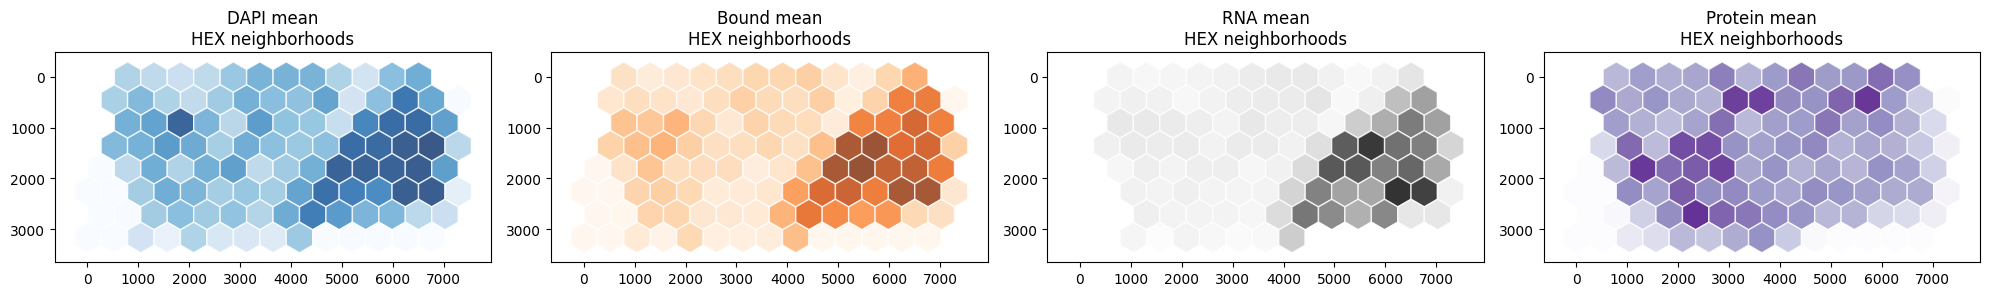

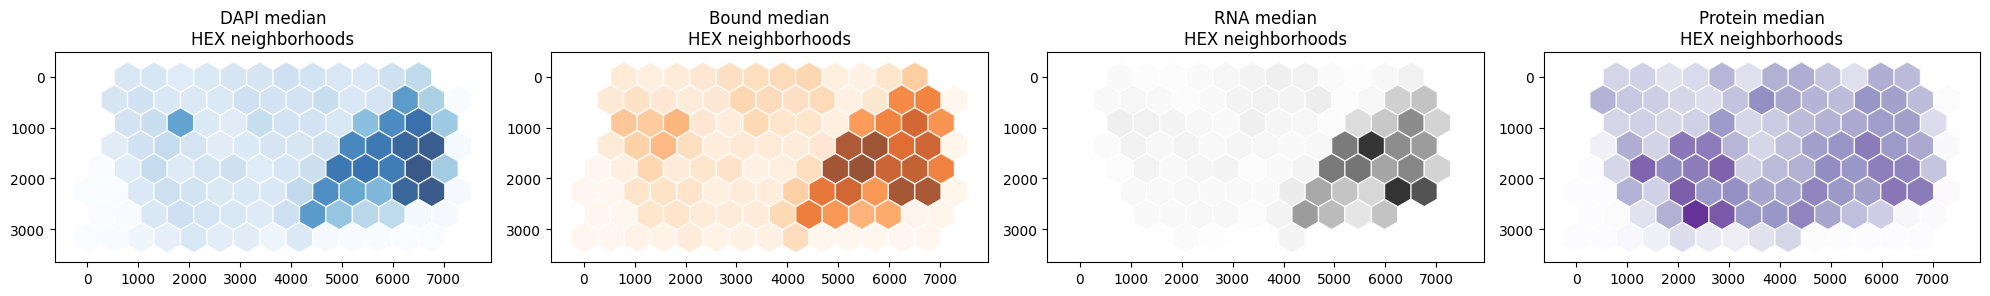

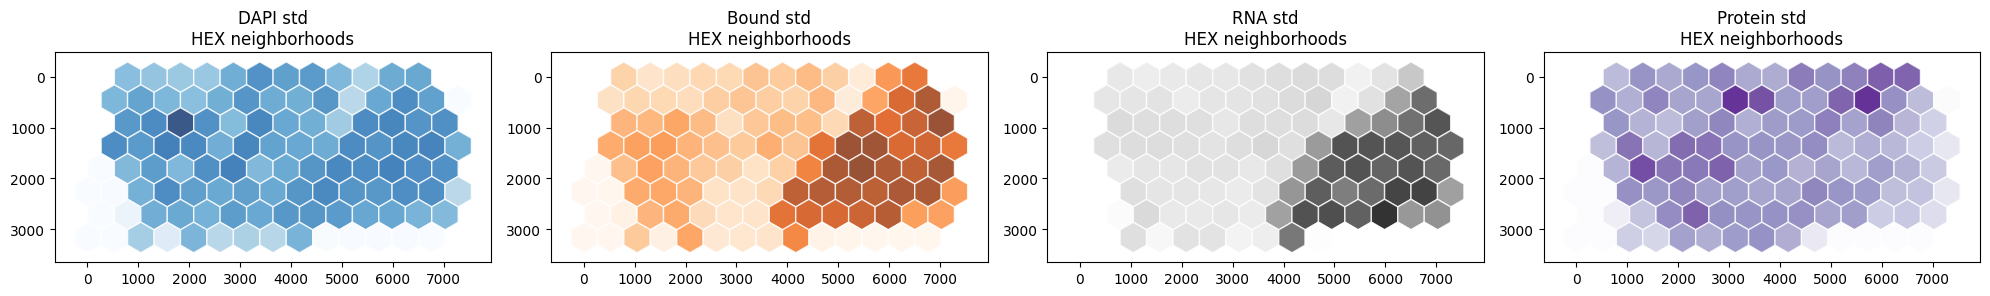

In [7]:
# Retrieve and visualize
metrics = ['mean','median','std']
for metric in metrics:
    gdf_nbi = nbhd.get_derived('NBI', metric)

    if metric == 'mean':
        print (f'NBI data example, metric:{metric}')
        display(gdf_nbi.head(3))       

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,7))
    
    # DAPI plot (leftmost)
    gdf_nbi.plot('dapi', ax=ax1, aspect=1, cmap='Blues', edgecolor='white', alpha=0.8)
    ax1.set_title(f'DAPI {metric}\n{nbhd_type} neighborhoods')
    ax1.invert_yaxis()
    
    # Bound plot (second)
    gdf_nbi.plot('bound', ax=ax2, aspect=1, cmap='Oranges', edgecolor='white', alpha=0.8)
    ax2.set_title(f'Bound {metric}\n{nbhd_type} neighborhoods')
    ax2.invert_yaxis()
    
    # RNA plot (third)
    gdf_nbi.plot('rna', ax=ax3, aspect=1, cmap='Greys', edgecolor='white', alpha=0.8)
    ax3.set_title(f'RNA {metric}\n{nbhd_type} neighborhoods')
    ax3.invert_yaxis()
    
    # Protein plot (rightmost)
    gdf_nbi.plot('prot', ax=ax4, aspect=1, cmap='Purples', edgecolor='white', alpha=0.8)
    ax4.set_title(f'Protein {metric}\n{nbhd_type} neighborhoods')
    ax4.invert_yaxis()
    
    plt.tight_layout()
    plt.show()

### NBG

NBG-CD data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 158.96586, 787.98189 308....",0.000000,0.000000,0.000000,0.772737,0.173133,0.062084,0.032683,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.031876,0.042707,0.000000,0.185789
1,hex_1,"POLYGON ((1567.40476 158.96586, 1307.59713 308...",0.001250,0.007116,0.003249,0.194614,0.350486,0.050209,0.007671,0.001495,...,0.015175,0.017116,0.001019,0.133779,0.000809,0.000583,0.670819,0.014144,0.023947,0.013626
2,hex_2,"POLYGON ((2087.02000 158.96586, 1827.21238 308...",0.001479,0.071686,0.010565,0.146276,0.125288,0.074480,0.063328,0.003877,...,0.072346,0.026901,0.003434,0.017030,0.001338,0.001371,0.457219,0.040790,0.043355,0.061262


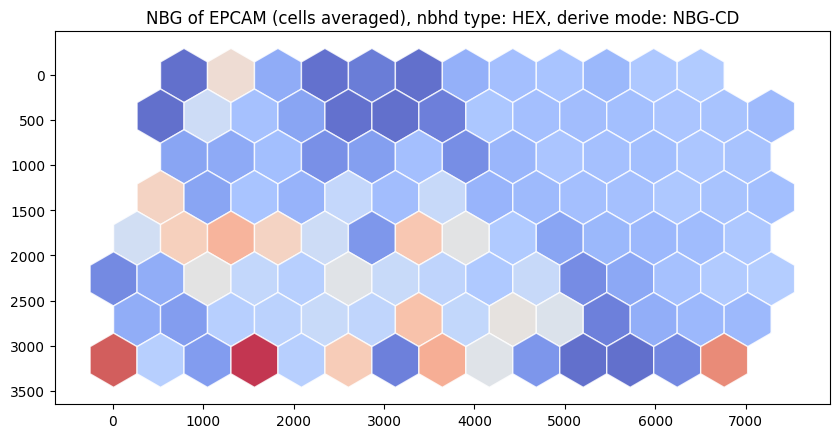

NBG-LCD data example, cluster:1


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,TRAC,TREM2,TSPAN19,UBE2C,UMOD,UPK3B,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 158.96586, 787.98189 308....",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,hex_1,"POLYGON ((1567.40476 158.96586, 1307.59713 308...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,hex_2,"POLYGON ((2087.02000 158.96586, 1827.21238 308...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


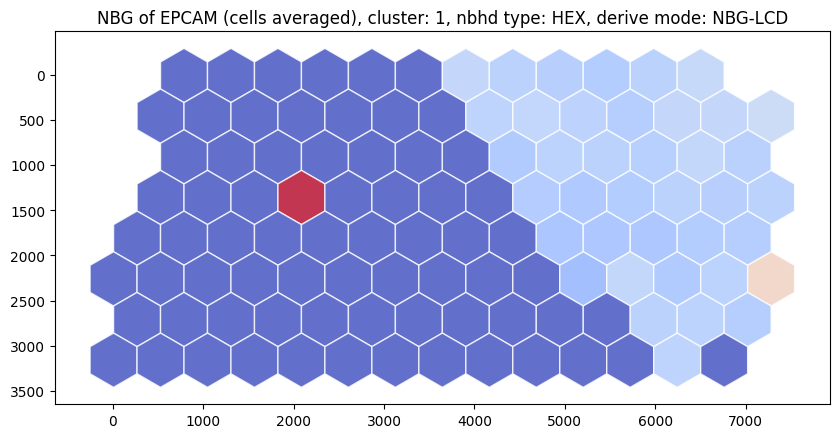

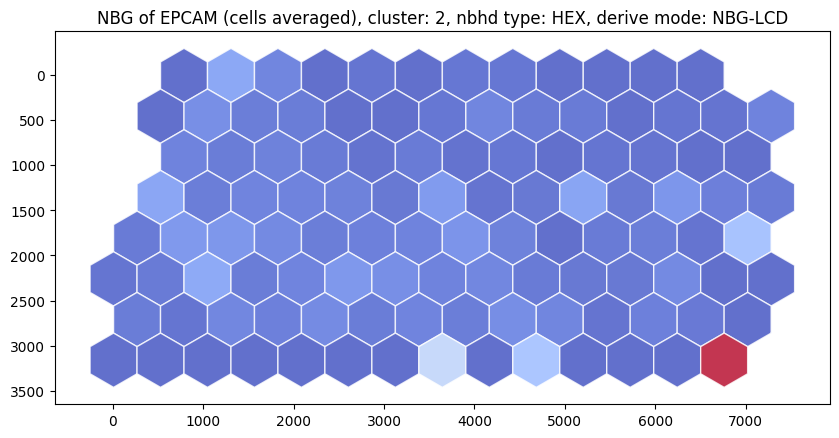

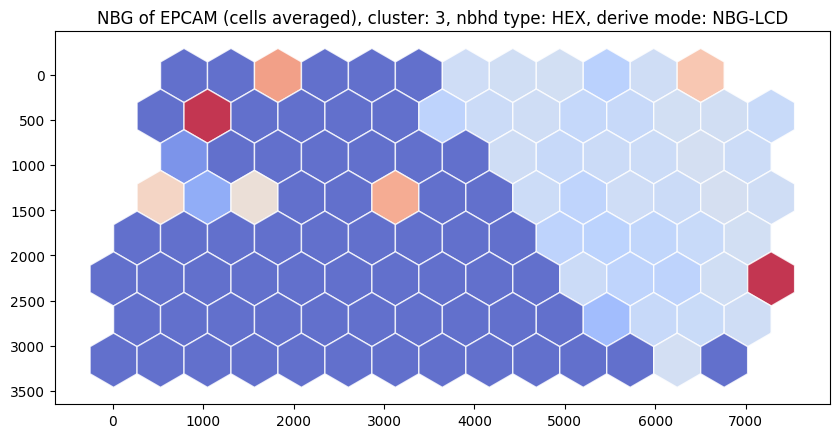

NBG-CF data example


,nbhd_id,geometry,ABCC11,ACE2,ACKR1,ACTA2,ACTG2,ADAM28,ADAMTS1,ADGRE1,...,UnassignedCodeword_0494,UnassignedCodeword_0495,UnassignedCodeword_0496,UnassignedCodeword_0497,UnassignedCodeword_0498,UnassignedCodeword_0499,VCAN,VSIG4,VWA5A,VWF
0,hex_0,"POLYGON ((1047.78951 158.96586, 787.98189 308....",1,0,0,65,18,2,4,0,...,0,0,0,0,0,0,153,3,0,15
1,hex_1,"POLYGON ((1567.40476 158.96586, 1307.59713 308...",1,12,7,413,882,81,11,4,...,0,2,0,0,0,0,1503,21,46,19
2,hex_2,"POLYGON ((2087.02000 158.96586, 1827.21238 308...",1,120,15,348,178,105,106,3,...,2,3,2,0,1,0,1306,68,58,123


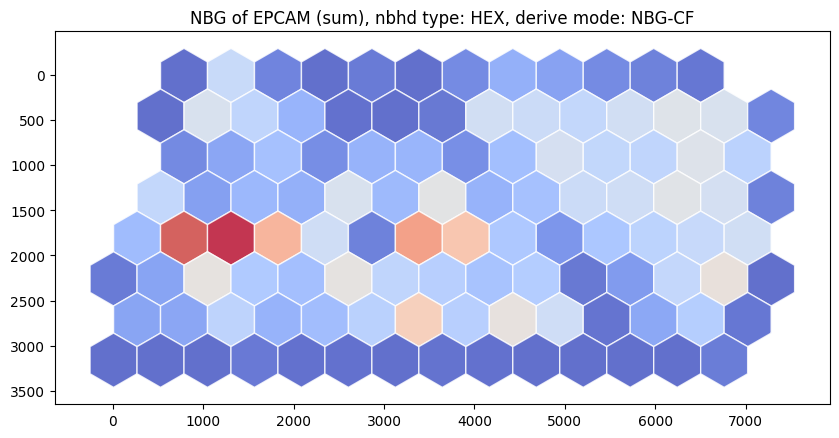

In [9]:
gene = 'EPCAM'

# Retrieve and visualize
gdf_nbg_cd = nbhd.get_derived('NBG-CD')
print ('NBG-CD data example')
display(gdf_nbg_cd.head(3))

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (cells averaged), nbhd type: {nbhd_type}, derive mode: NBG-CD')
ax.invert_yaxis()
plt.show()

# Retrieve and visualize
clusters = ['1','2','3']
for cluster in clusters:
    gdf_nbg_lcd = nbhd.get_derived('NBG-LCD', cluster)

    if cluster == '1':
        print (f'NBG-LCD data example, cluster:{cluster}')
        display(gdf_nbg_lcd.head(3))       

    fig, ax = plt.subplots(figsize=(10, 5))                           
    gdf_nbg_lcd.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'NBG of {gene} (cells averaged), cluster: {cluster}, nbhd type: {nbhd_type}, derive mode: NBG-LCD')       
    ax.invert_yaxis()
    plt.show()


# Retrieve and visualize
gdf_nbg_cf = nbhd.get_derived('NBG-CF')

print ('NBG-CF data example')
display(gdf_nbg_cf.head(3))

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbg_cf.plot(gene, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBG of {gene} (sum), nbhd type: {nbhd_type}, derive mode: NBG-CF')
ax.invert_yaxis()
plt.show()


### NBP

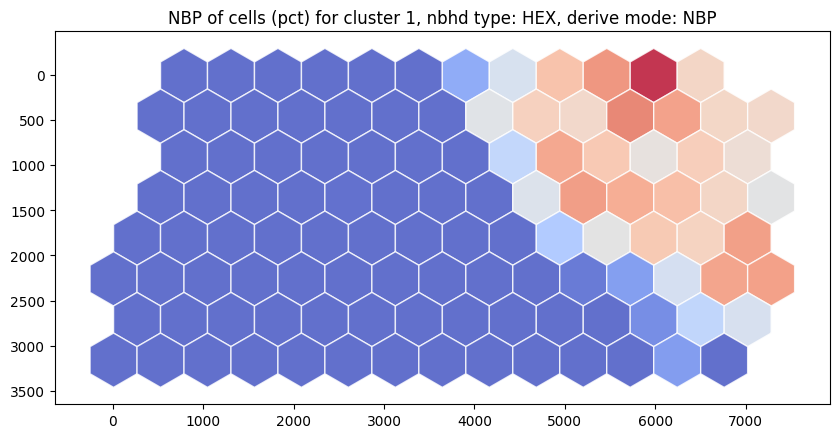

In [10]:
# Retrieve and visualize
sub_key = 'pct'
cluster_name = '1'

gdf_nbp = nbhd.get_derived('NBP', sub_key)

fig, ax = plt.subplots(figsize=(10, 5))                           
gdf_nbp.plot(cluster_name, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
ax.set_title(f'NBP of cells ({sub_key}) for cluster {cluster_name}, nbhd type: {nbhd_type}, derive mode: NBP')
ax.invert_yaxis()
plt.show()

### NBM (metadata)

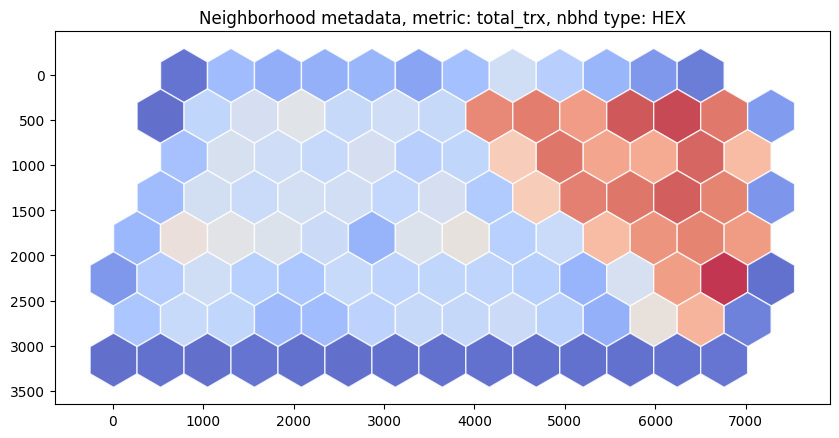

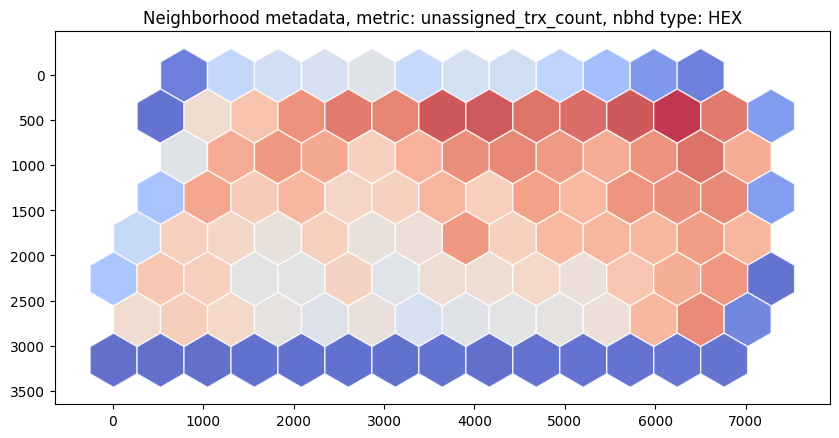

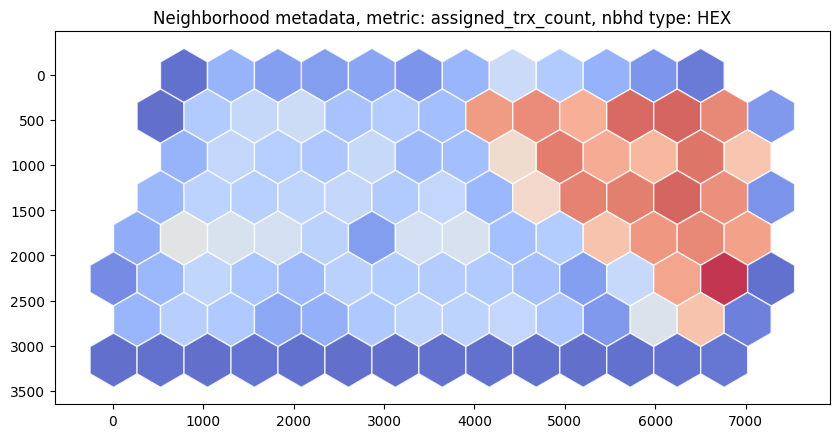

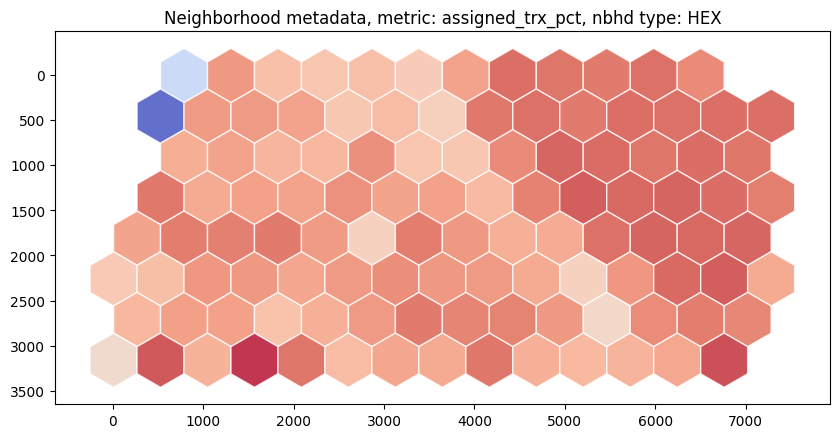

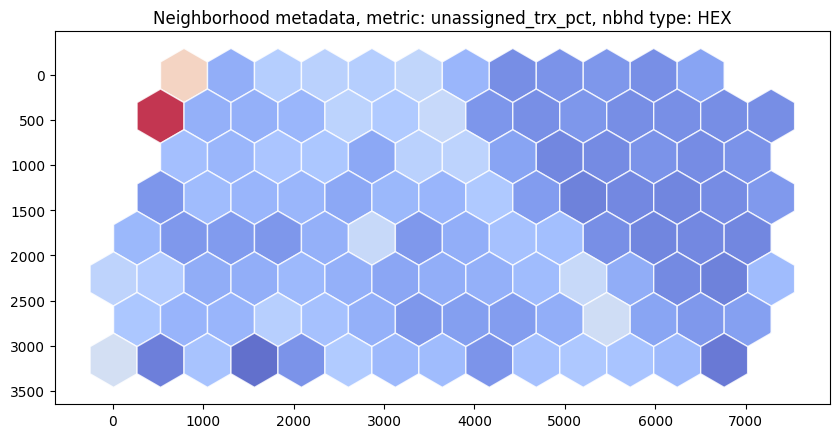

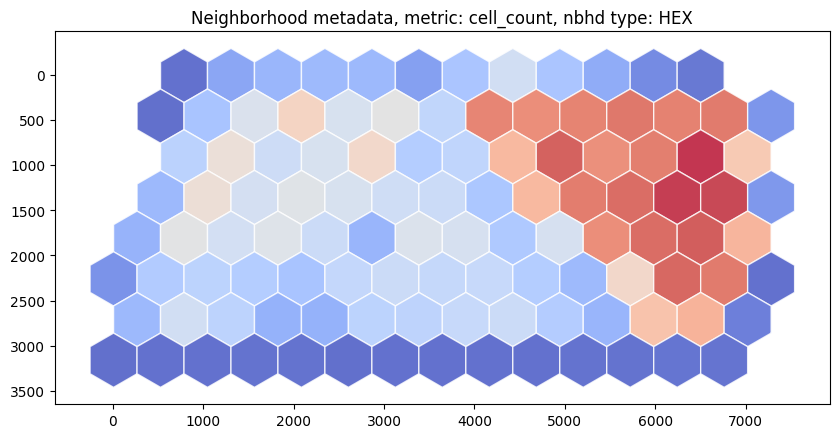

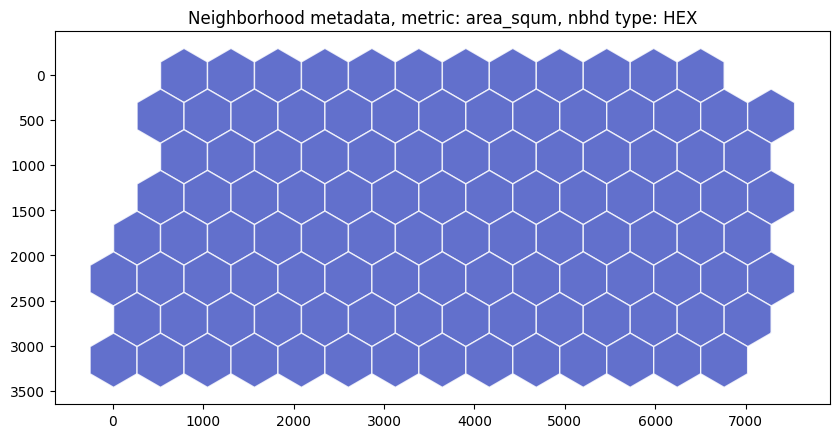

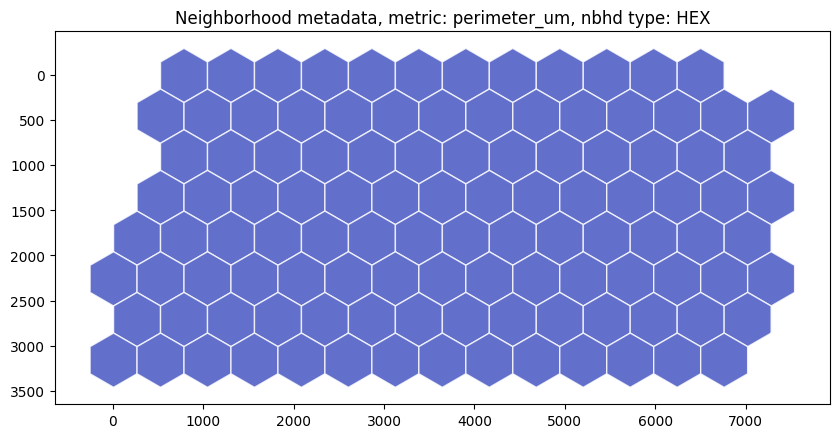

In [11]:
meta = nbhd.get_derived('NBM')

for metric in meta.select_dtypes(include='number').columns:
    fig, ax = plt.subplots(figsize=(10, 5))                           
    meta.plot(metric, ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
    ax.set_title(f'Neighborhood metadata, metric: {metric}, nbhd type: {nbhd_type}')
    ax.invert_yaxis()
    plt.show()

# Neighborhood by neighborhood

ALPH
calculating neighborhood overlap
(49, 4)


,nbhd_1,nbhd_2,overlap_area,geometry
0,0_35,2_35,4679966.74,"MULTIPOLYGON (((313.206 2859.320, 323.670 2863..."
1,0_35,1_35,34152.73,"MULTIPOLYGON (((6632.260 2752.140, 6628.363 27..."
2,0_35,3_35,86889.75,"MULTIPOLYGON (((6696.800 2740.560, 6691.240 27..."
3,0_35,5_35,297301.74,"MULTIPOLYGON (((6716.072 2741.804, 6702.230 27..."
4,0_35,6_35,27883.91,"MULTIPOLYGON (((6435.489 2778.942, 6458.940 27..."


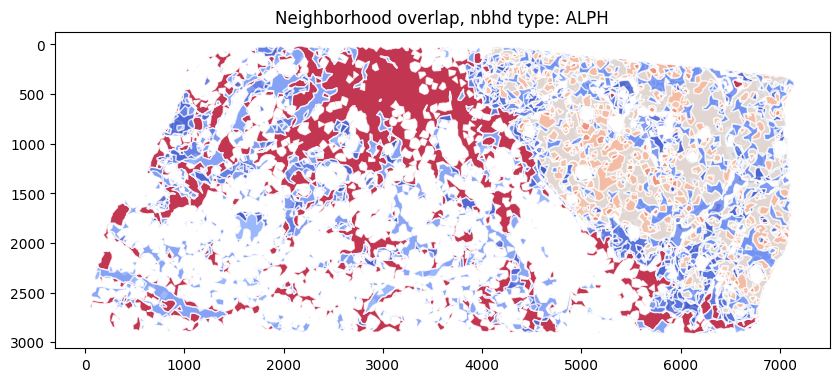

pivoted matrix


,0_35,10_35,1_35,2_35,3_35,4_35,5_35,6_35,7_35,8_35,9_35
0_35,NaN,12425.00,34152.73,4679966.74,86889.75,764157.63,297301.74,27883.91,637836.70,1026608.62,39657.38
10_35,12425.00,0.00,935449.19,31810.22,907615.12,0.00,755690.86,769024.86,58210.66,13642.15,3421.13
1_35,34152.73,935449.19,0.00,95054.43,3843267.53,0.00,2943534.21,3196554.21,283395.54,19837.35,34487.28
2_35,4679966.74,31810.22,95054.43,0.00,163217.27,240085.50,601852.44,107987.58,592361.43,1054802.86,19616.26
3_35,86889.75,907615.12,3843267.53,163217.27,0.00,0.00,2876013.72,2976043.83,448579.30,39194.98,52438.54
4_35,764157.63,0.00,0.00,240085.50,0.00,0.00,0.00,0.00,10221.88,27540.88,0.00
5_35,297301.74,755690.86,2943534.21,601852.44,2876013.72,0.00,0.00,2351732.16,423409.85,138812.96,34036.30
6_35,27883.91,769024.86,3196554.21,107987.58,2976043.83,0.00,2351732.16,0.00,192429.44,24778.17,17595.19
7_35,637836.70,58210.66,283395.54,592361.43,448579.30,10221.88,423409.85,192429.44,0.00,206143.71,12580.99
8_35,1026608.62,13642.15,19837.35,1054802.86,39194.98,27540.88,138812.96,24778.17,206143.71,0.00,14818.21


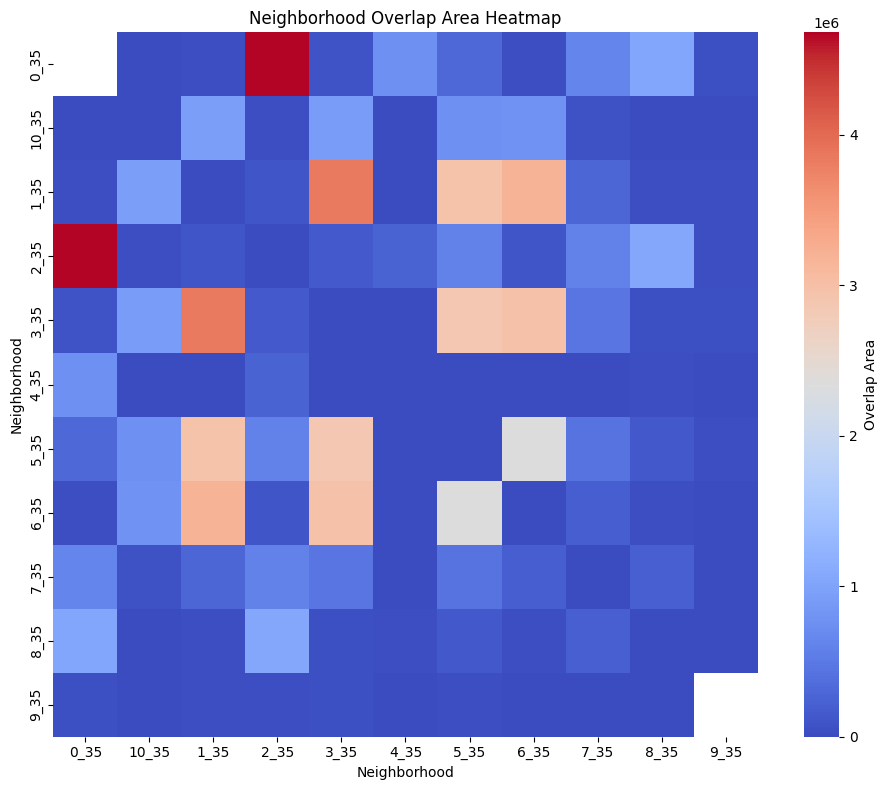

HEX
calculating neighborhood bordering
(98, 2)


,nbhd_1,nbhd_2
0,hex_0,hex_1
1,hex_0,hex_13
2,hex_1,hex_14
3,hex_2,hex_3
4,hex_4,hex_5


SKTCH
calculating neighborhood bordering
(0, 2)


,nbhd_1,nbhd_2


GRAD
calculating neighborhood bordering
(28, 2)


,nbhd_1,nbhd_2
0,grad_0,grad_1
1,grad_1,grad_2
2,grad_2,grad_3
3,grad_3,grad_4
4,grad_4,grad_5


In [12]:

for nbhd_type_test in ['ALPH', 'HEX', 'SKTCH', 'GRAD']:
    print (nbhd_type_test)
    gdf_nbhd = nbhd_lookup[nbhd_type_test]
    nb = gdf_nbhd[['name','geometry']]


    if nbhd_type_test == 'ALPH':
        print ('calculating neighborhood overlap')
        df_nn = dega.nbhd.calc_nb_overlap(nb)
        print (df_nn.shape)
        display(df_nn.head(5))

        if len(df_nn) > 0:
            fig, ax = plt.subplots(figsize=(10, 5))                           
            df_nn.plot('overlap_area', ax=ax, aspect=1, cmap='coolwarm', edgecolor='white', alpha=0.8)
            ax.set_title(f'Neighborhood overlap, nbhd type: {nbhd_type_test}')
            ax.invert_yaxis()
            plt.show()

            # Step 1: Pivot the data into a matrix
            df_matrix = df_nn.pivot(index="nbhd_1", columns="nbhd_2", values="overlap_area")

            # Step 2: Fill NaNs with 0 (no overlap) and make symmetric (optional but cleaner)
            df_matrix = df_matrix.fillna(0)
            df_matrix = df_matrix.add(df_matrix.T, fill_value=0)  # Symmetrize

            print ('pivoted matrix')
            display(df_matrix)

            # Step 3: Plot heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(df_matrix, cmap="coolwarm", annot=False, square=True, cbar_kws={'label': 'Overlap Area'})
            plt.title("Neighborhood Overlap Area Heatmap")
            plt.xlabel("Neighborhood")
            plt.ylabel("Neighborhood")
            plt.tight_layout()
            plt.show()
    else:
        print ('calculating neighborhood bordering')
        df_nn = dega.nbhd.calc_nb_bordering(nb)
        print (df_nn.shape)
        display(df_nn.head(5))


# Anndata and Mudata testing

In [37]:
import pandas as pd
from anndata import AnnData
from mudata import MuData
import mudata as md
import muon as mu

def _to_adata(df):
    # df.fillna(0, inplace=True)
    adata = AnnData(X=df.values)
    adata.obs = pd.DataFrame(index=df.index.astype(str))
    adata.var = pd.DataFrame(index=df.columns.astype(str))
    return adata

munbhd = MuData({
    "nbg-cd": _to_adata(nbg_cd),   # gene expression
    "nbg-cf": _to_adata(nbg_cf),   # gene expression   
    "nbp": _to_adata(df_nbp),    # population proportions
    "nbi": _to_adata(nbi_dict['median'])# image intensity
})

munbhd.write(f"{path_landscape_files}/nhbd_collections.h5mu")  

In [38]:
# Load the h5mu file
mdata = mu.read(f"{path_landscape_files}/nhbd_collections.h5mu")
adata = mdata['nbg-cd']
meta = nbhd.get_derived('NBM')

add_centroids_to_obsm(adata, meta, key="spatial")
meta["geometry"] = meta.geometry.apply(_to_coords)
adata.obs = meta

adata

AnnData object with n_obs × n_vars = 110 × 377
    obs: 'nbhd_id', 'geometry', 'total_trx', 'unassigned_trx_count', 'assigned_trx_count', 'assigned_trx_pct', 'unassigned_trx_pct', 'cell_count', 'area_squm', 'perimeter_um'
    obsm: 'spatial'

<Axes: title={'center': 'cell_count per nbhd'}, xlabel='cell_count', ylabel='Count'>

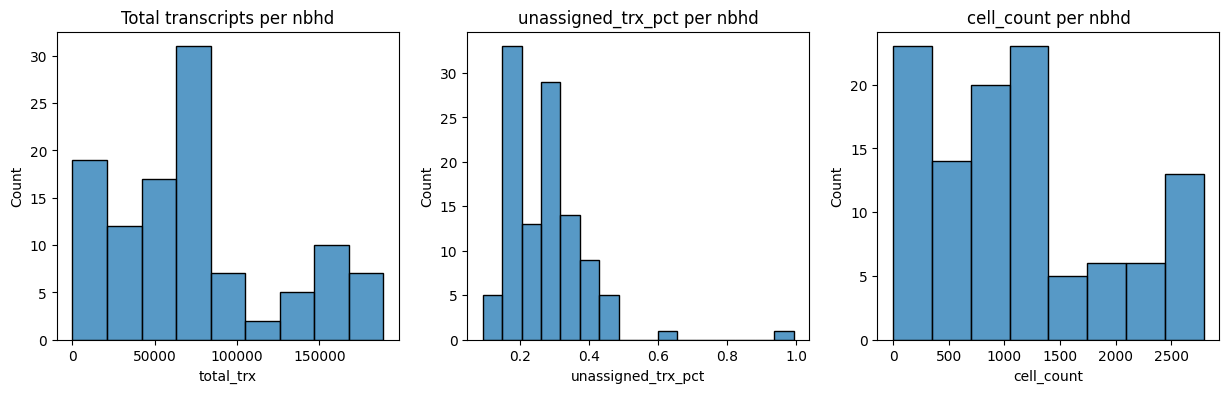

In [39]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].set_title("Total transcripts per nbhd")
sns.histplot(
    adata.obs["total_trx"],
    kde=False,
    ax=axs[0],
)

axs[1].set_title("unassigned_trx_pct per nbhd")
sns.histplot(
    adata.obs["unassigned_trx_pct"],
    kde=False,
    ax=axs[1],
)


axs[2].set_title("cell_count per nbhd")
sns.histplot(
    adata.obs["cell_count"],
    kde=False,
    ax=axs[2],
)


In [40]:
# Derived data
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=2.0)

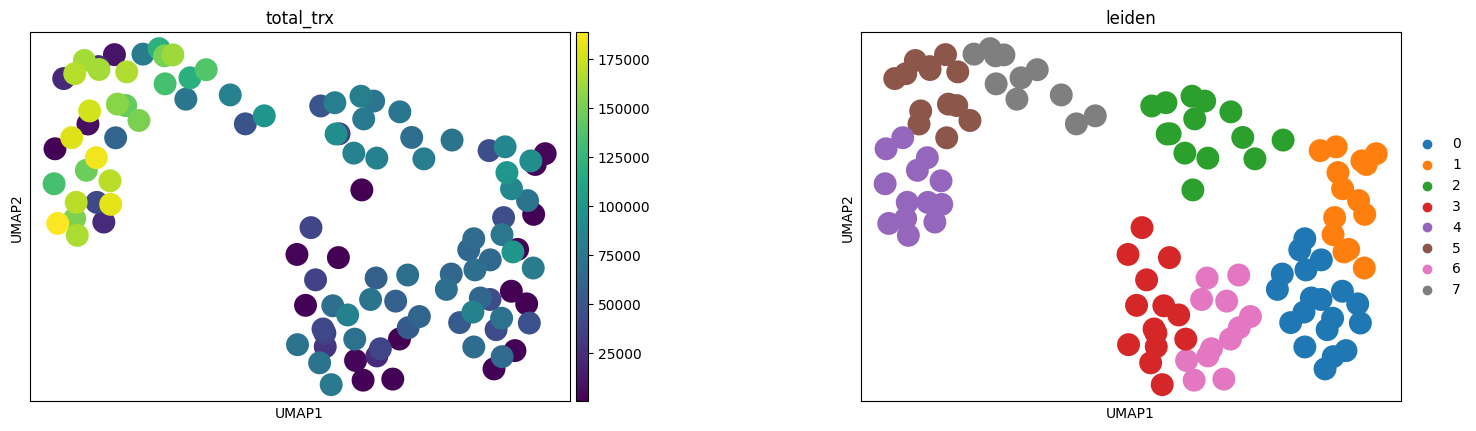

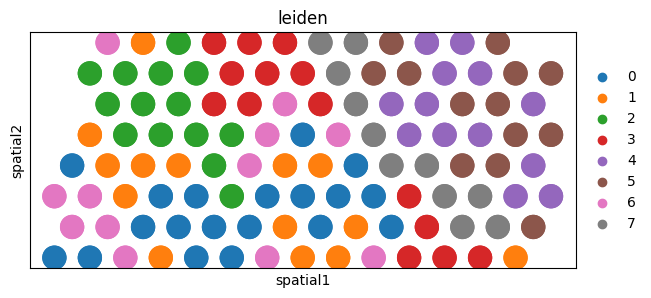

In [41]:
# Plotting 
sc.pl.umap(
    adata,
    color=[
        "total_trx",
        "leiden",
    ],
    wspace=0.4,
)

sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    shape=None,
    color=[
        "leiden",
    ],
    wspace=0.4,
)

### Build neighborhood graph

In [42]:
# Building a spatial neighborhood graph 
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

### Compute centrality score
Centrality scores are calculated with squidpy.gr.centrality_scores, with the Leiden groups as clusters.

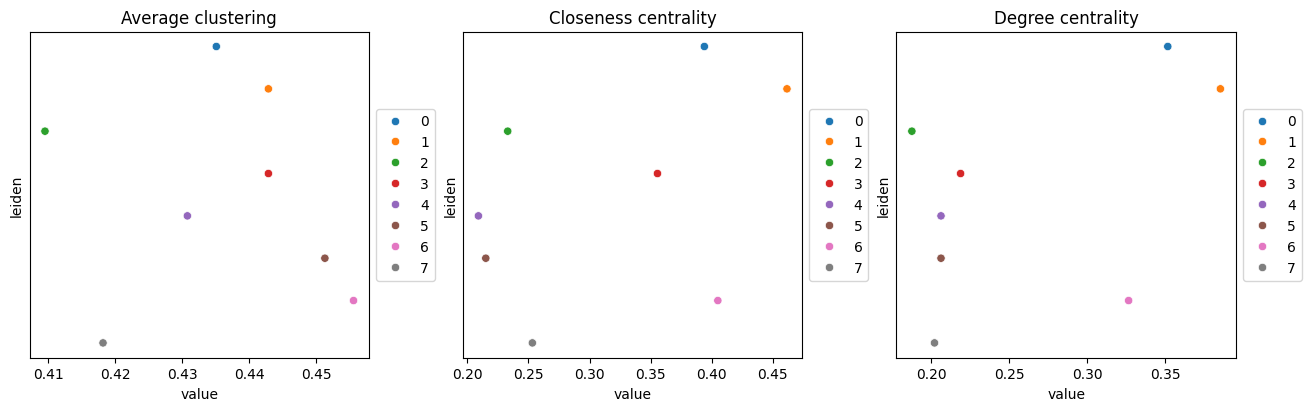

In [43]:
# Compute centrality scores
sq.gr.centrality_scores(adata, cluster_key="leiden")
sq.pl.centrality_scores(adata, cluster_key="leiden", figsize=(13, 4))

### Compute co-occurrence probability

  0%|          | 0/1 [00:00<?, ?/s]

/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


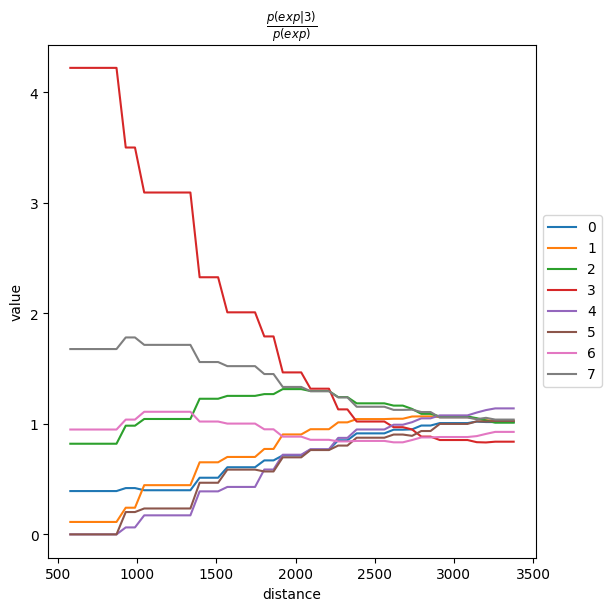

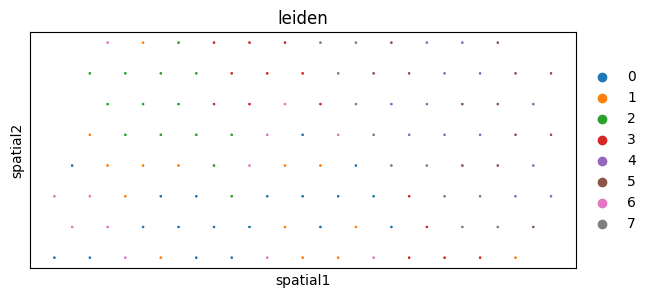

In [44]:
adata.obs['cell_id'] = adata.obs.index # Add a cell_id column using index


sq.gr.co_occurrence(
    adata,
    cluster_key="leiden",
)
sq.pl.co_occurrence(
    adata,
    cluster_key="leiden",
    clusters="3",
    figsize=(6, 6),
)
sq.pl.spatial_scatter(
    adata,
    color="leiden",
    shape=None,
    size=2,
)

### Neighbors enrichment analysis

  0%|          | 0/1000 [00:00<?, ?/s]

/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/whuan/miniconda3/envs/celldega_env/lib/python3.12/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


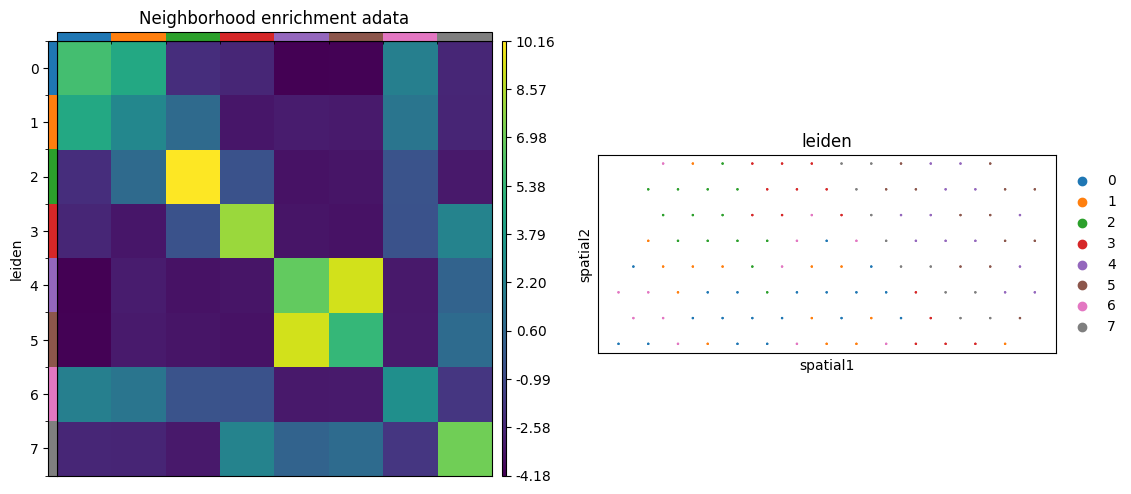

In [45]:
sq.gr.nhood_enrichment(adata, cluster_key="leiden")

fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden",
    figsize=(5,5),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata, color="leiden", shape=None, size=2, ax=ax[1])

In [46]:
adata

AnnData object with n_obs × n_vars = 110 × 377
    obs: 'nbhd_id', 'geometry', 'total_trx', 'unassigned_trx_count', 'assigned_trx_count', 'assigned_trx_pct', 'unassigned_trx_pct', 'cell_count', 'area_squm', 'perimeter_um', 'leiden', 'cell_id'
    uns: 'log1p', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'spatial_neighbors', 'leiden_centrality_scores', 'leiden_co_occurrence', 'leiden_nhood_enrichment'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'